# TP1 — EDA & Nettoyage du dataset Lumina & Co

**Cours :** Data Marketing et Analytics — DIA2 — HETIC
**Jour 1 :** *"On envoie les mêmes emails à tout le monde, c'est un problème ?"*

Le data engineer de Lumina & Co nous a livré deux fichiers extraits du CRM : `customers.csv` et `transactions.csv`.
Avant de pouvoir segmenter quoi que ce soit (Jour 2), on doit comprendre ce qu'on a et corriger les problèmes.

> *"Je vous préviens, l'export n'est pas parfait. Ça vient de notre CRM, et quelques listes que des employés tenaient à jour de leur côté."*
> — le data engineer

Ce notebook suit les 4 étapes du TP :
1. Chargement et premier diagnostic
2. Détection et traitement des anomalies (transactions puis customers)
3. EDA orientée marketing
4. Formulation d'hypothèses marketing pour le Jour 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PALETTE = {
    "primary": "#5B4FCF",
    "secondary": "#2FB4A6",
    "warn": "#E0793C",
    "bad": "#D64550",
    "neutral": "#8891A5",
}

## Étape 1 — Chargement

In [ ]:
customers = pd.read_csv("Lumina & Co - CRM/customers.csv")
transactions = pd.read_csv("Lumina & Co - CRM/transactions.csv")

customers["first_purchase"] = pd.to_datetime(customers["first_purchase"])
customers["last_purchase"] = pd.to_datetime(customers["last_purchase"])
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])

print(f"customers.csv     : {customers.shape[0]:,} clients, {customers.shape[1]} colonnes".replace(",", " "))
print(f"transactions.csv  : {transactions.shape[0]:,} lignes, {transactions.shape[1]} colonnes".replace(",", " "))
print(f"Période transactions : {transactions['invoice_date'].min().date()} -> {transactions['invoice_date'].max().date()}")
print(f"Période customers (first_purchase) : {customers['first_purchase'].min().date()} -> {customers['first_purchase'].max().date()}")

**Combien de clients ? Combien de transactions ? Sur quelle période ?**

- `customers.csv` : **50 295 clients** (un profil par client, un `customer_id` unique).
- `transactions.csv` : **1 613 433 lignes** (une ligne par produit dans une facture), sur **~4 ans et demi**, de janvier 2022 à juin 2026.
- La période de `customers.csv` (premières commandes depuis fin 2021) est cohérente avec celle de `transactions.csv`.

In [3]:
print("=== Types de données observés ===\n")
print("customers.csv:\n", customers.dtypes, "\n")
print("transactions.csv:\n", transactions.dtypes)

=== Types de données observés ===

customers.csv:
 customer_id                     int64
country                           str
first_purchase         datetime64[us]
last_purchase          datetime64[us]
n_orders                        int64
total_spent                   float64
avg_basket                    float64
recency_days                    int64
tenure_days                     int64
declared_preference               str
age_bracket                       str
life_stage                        str
urban_density                     str
dtype: object 

transactions.csv:
 invoice_id                 str
customer_id            float64
product_code               str
product_name               str
category                   str
quantity                 int64
unit_price             float64
invoice_date    datetime64[us]
country                    str
dtype: object


**Types attendus vs observés :** dans l'ensemble, les types sont cohérents avec ce qu'on attend (identifiants en entier,
montants en flottant, dates lisibles). Deux points à noter :
- `customer_id` est en `float64` dans `transactions.csv` à cause des valeurs manquantes (pandas force le float dès qu'une
  colonne d'entiers contient des `NaN`) — pas un vrai problème de type, mais un signal qu'il faut gérer ces manquants.
- Les dates (`invoice_date`, `first_purchase`, `last_purchase`) sont chargées en texte par défaut ; on les convertit
  explicitement en `datetime` ci-dessus.

In [4]:
print("=== Valeurs manquantes — customers.csv ===")
na_c = customers.isna().sum()
pct_c = (na_c / len(customers) * 100).round(2)
display(pd.DataFrame({"n_manquants": na_c, "%_manquants": pct_c}).query("n_manquants > 0"))

print("\n=== Valeurs manquantes — transactions.csv ===")
na_t = transactions.isna().sum()
pct_t = (na_t / len(transactions) * 100).round(2)
display(pd.DataFrame({"n_manquants": na_t, "%_manquants": pct_t}).query("n_manquants > 0"))

=== Valeurs manquantes — customers.csv ===


,n_manquants,%_manquants
declared_preference,31108,61.85
age_bracket,28821,57.30
life_stage,38986,77.51
urban_density,40332,80.19



=== Valeurs manquantes — transactions.csv ===


,n_manquants,%_manquants
customer_id,367328,22.77
product_name,2241,0.14


In [5]:
print("=== Doublons ===")
print(f"customers.csv    : {customers.duplicated().sum()} doublons stricts, {customers.duplicated(subset=['customer_id']).sum()} customer_id dupliqués")
print(f"transactions.csv : {transactions.duplicated().sum()} lignes strictement dupliquées (toutes colonnes identiques)")

=== Doublons ===


customers.csv    : 0 doublons stricts, 0 customer_id dupliqués


transactions.csv : 445 lignes strictement dupliquées (toutes colonnes identiques)


### Data quality report — 5 observations clés (avant nettoyage)

1. **`customer_id` manquant sur 22,8 % des lignes de `transactions.csv`** (367 328 lignes, 102 713 factures) — un
   quart du chiffre d'affaires n'est aujourd'hui rattachable à *aucun* client. C'est directement lié à la question du
   CMO : on ne peut pas segmenter ce qu'on n'arrive pas à relier à un client.
2. **Les données zero-party de `customers.csv` sont très incomplètes** : `declared_preference` (62 % manquant),
   `age_bracket` (57 %), `life_stage` (78 %), `urban_density` (80 %). Attendu pour du déclaratif, mais ça limite fortement
   toute segmentation basée sur ces colonnes.
3. **`transactions.csv` contient des lignes qui ne sont pas des ventes produit** : retours (`quantity` négative,
   2,15 % des lignes), remises et frais (`unit_price` à 0 ou négatif, catégorie `Frais` avec des codes comme `POST`,
   `M`, `DOT`, `D`) — à isoler avant tout calcul de CA ou de panier moyen.
4. **Les agrégats pré-calculés de `customers.csv` (`n_orders`, `total_spent`, `tenure_days`) ne se recalculent pas
   exactement depuis `transactions.csv`** : 983 clients de `customers.csv` n'ont aucune transaction correspondante, et
   pour la grande majorité des autres, `total_spent` diffère de la somme des lignes. `tenure_days` ne correspond ni à
   "jours depuis la 1ère commande" ni exactement à "durée entre 1ère et dernière commande" pour ~11 % des clients.
   → ces champs proviennent probablement d'un calcul CRM fait à un autre moment / sur un périmètre différent.
5. **Un bloc de 131 `customer_id` (62600-62730) a un profil démographique et comportemental très différent** du reste
   de la base (sur-représentation Israël/Grèce, paniers moyens nettement plus élevés, souvent une seule commande) —
   probablement la "liste tenue à jour par des employés" mentionnée par le data engineer, fusionnée après coup.

Aucun de ces points n'est traité pour l'instant — on documente d'abord, on corrige ensuite.

## Étape 2 — Détection et traitement des anomalies

### `transactions.csv`

#### `customer_id` manquants

In [6]:
miss_cust = transactions[transactions["customer_id"].isna()]
print(f"{len(miss_cust):,} lignes ({len(miss_cust)/len(transactions)*100:.1f} %), {miss_cust['invoice_id'].nunique():,} factures distinctes".replace(",", " "))
display(miss_cust["category"].value_counts(normalize=True).mul(100).round(1).rename("% des lignes sans customer_id"))

367 328 lignes (22.8 %)  102 713 factures distinctes


category
Visage        28.3
Corps         23.6
Cheveux       14.6
Accessoire    13.4
Bain          11.7
Coffret        7.6
Frais          0.7
Name: % des lignes sans customer_id, dtype: float64

**Que représentent ces lignes ?** Ce sont des ventes produit tout à fait normales (mêmes catégories, mêmes gammes de
prix et de quantité que le reste) — seul le lien vers un client a été perdu à l'extraction, probablement des ventes
en caisse / guest checkout non rattachées à un compte CRM, ou une jointure défaillante côté export.

**Décision :** on **conserve** ces lignes — les supprimer reviendrait à sous-estimer le chiffre d'affaires réel et
fausserait la saisonnalité et les KPIs de catégorie. Mais comme elles ne peuvent être imputées à aucun client sans
risque d'erreur (inventer un `customer_id` serait pire que de le laisser manquant), on les **exclut de toute analyse
au niveau client** (segmentation RFM du Jour 2). On matérialise ça avec un flag `has_customer_id`.

#### `quantity` négatives

In [7]:
neg_q = transactions[transactions["quantity"] < 0]
is_credit_note = neg_q["invoice_id"].astype(str).str.startswith("C")
print(f"{len(neg_q):,} lignes à quantity négative ({len(neg_q)/len(transactions)*100:.2f} %)".replace(",", " "))
print(f"  dont sur facture 'C...' (note de crédit) : {is_credit_note.sum():,}".replace(",", " "))
print(f"  dont sur facture numérique normale        : {(~is_credit_note).sum():,}".replace(",", " "))

34 691 lignes à quantity négative (2.15 %)
  dont sur facture 'C...' (note de crédit) : 19 493
  dont sur facture numérique normale        : 15 198


**D'où viennent-elles ?** Deux populations bien distinctes :
- **Factures préfixées `C`** (19 493 lignes) : convention classique de note de crédit / retour. C'est un événement
  business légitime et attendu — un client retourne un produit.
- **Factures numériques "normales" avec quantité négative** (15 198 lignes) : aucune convention de retour associée.
  Plus probablement des erreurs de saisie (signe inversé) qu'un vrai retour.

**Impact sur les agrégations futures :** si on ne les distingue pas, elles feront baisser artificiellement le CA et
les quantités vendues dans les KPIs de campagne (Jour 3).

**Décision :** on garde toutes ces lignes (aucune n'est à supprimer, ce sont des mouvements réels ou au minimum des
données qu'on ne peut pas corriger sans information supplémentaire), mais on les flague : `is_return` pour les
factures `C` (à traiter comme un retour dans le CA net), `is_return_suspect` pour le reste (à ne pas traiter comme
un retour "propre", à documenter comme limite).

#### `unit_price` à zéro et à zéro négatif

In [8]:
zero_p = transactions[transactions["unit_price"] == 0]
neg_p = transactions[transactions["unit_price"] < 0]
print(f"unit_price == 0 : {len(zero_p):,} lignes ({len(zero_p)/len(transactions)*100:.2f} %)".replace(",", " "))
display(zero_p["product_name"].value_counts().head(6))
print(f"\nunit_price < 0  : {len(neg_p):,} lignes — toutes sur product_code 'D' (Remise commerciale)".replace(",", " "))
display(neg_p[["product_code", "product_name", "category"]].drop_duplicates())

unit_price == 0 : 10 897 lignes (0.68 %)


product_name
Ajustement manuel                 1426
Contour des Yeux Concombre         434
Brosse Corps Fibres Naturelles     411
Trousse Voyage Rechargeable        408
Savon Surgras Lavande              408
Lait Corps Amande Douce            403
Name: count, dtype: int64


unit_price < 0  : 177 lignes — toutes sur product_code 'D' (Remise commerciale)


,product_code,product_name,category
3238,D,Remise commerciale,Frais


**Anomalie ou cas métier légitime ?** Les deux à la fois, selon la ligne :
- `product_code == 'M'` ("Ajustement manuel") : ce sont des lignes d'ajustement comptable, pas des ventes produit.
- Le reste des lignes à prix 0 (~9 400) porte des noms de vrais produits (savons, laits corps, coffrets...) :
  cohérent avec des **échantillons ou cadeaux offerts** lors d'une commande — cas métier légitime, mais qui ne génère
  aucun revenu.
- `unit_price < 0` (177 lignes, toutes `product_code == 'D'`, "Remise commerciale") : des lignes de remise
  commerciale, toujours associées à une facture de type retour — cas métier légitime également.

**Décision :** on conserve ces lignes (elles ont un sens business) mais on les **exclut du calcul de revenu produit**
puisqu'elles ne représentent ni un achat au prix normal ni un vrai retour de produit facturé.

#### `product_code` atypiques — lignes non-produit

In [9]:
frais = transactions[transactions["category"] == "Frais"]
print(f"{len(frais):,} lignes en catégorie 'Frais' ({len(frais)/len(transactions)*100:.2f} %)".replace(",", " "))
display(frais["product_name"].value_counts())

7 465 lignes en catégorie 'Frais' (0.46 %)


product_name
Frais divers          3174
Frais de port         2122
Ajustement manuel     1426
Frais de carte         282
Remise commerciale     177
Échantillon            104
Frais bancaires        102
Frais marketplace       43
Emballage               19
Don caritatif           16
Name: count, dtype: int64

La catégorie `Frais` regroupe des lignes qui ne sont pas des produits vendus : frais de port (`POST`), frais divers
(`DOT`), ajustements manuels (`M`), frais de carte (`C2`/`C3`), remises commerciales (`D`), échantillons, frais
bancaires, frais marketplace, emballage, dons caritatifs.

**Décision :** ces lignes ne doivent **jamais entrer dans une analyse par catégorie de produit ou panier moyen
produit** (elles polluent la category `Frais` qui n'a pas de sens marketing) mais on les garde pour toute
réconciliation du chiffre d'affaires total facturé (frais de port compris).

#### `line_total` = `quantity × unit_price`, et cohérence

In [10]:
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]
print(transactions["line_total"].describe().round(2))
print(f"\nline_total < 0 : {(transactions['line_total'] < 0).sum():,} (cohérent avec retours + remises)".replace(",", " "))
print(f"line_total == 0 : {(transactions['line_total'] == 0).sum():,} (cohérent avec unit_price == 0)".replace(",", " "))

count    1613433.00
mean          31.37
std           29.59
min         -283.85
25%           14.41
50%           23.34
75%           41.10
max          288.65
Name: line_total, dtype: float64

line_total < 0 : 30 344 (cohérent avec retours + remises)
line_total == 0 : 10 897 (cohérent avec unit_price == 0)


**Vérification de cohérence :** le nombre de `line_total` négatifs (30 344) est cohérent avec la somme des retours et
remises identifiés ci-dessus, et le nombre de `line_total` nuls correspond exactement au nombre de lignes à
`unit_price == 0`. Pas d'incohérence supplémentaire détectée sur ce calcul.

#### Doublons stricts

In [11]:
dups = transactions.duplicated(keep="first")
print(f"{dups.sum()} lignes strictement dupliquées (même facture, produit, quantité, prix, horodatage)")

445 lignes strictement dupliquées (même facture, produit, quantité, prix, horodatage)


**Décision :** ce sont très probablement des doubles saisies (scan en double) — on les **supprime** en ne gardant
que la première occurrence.

In [12]:
transactions = transactions[~transactions.duplicated(keep="first")].reset_index(drop=True)
print(f"transactions.csv après suppression des doublons stricts : {len(transactions):,} lignes".replace(",", " "))

transactions.csv après suppression des doublons stricts : 1 612 988 lignes


### `customers.csv`

#### Cohérence des dates (`first_purchase` ≤ `last_purchase`)

In [13]:
bad_dates = customers[customers["first_purchase"] > customers["last_purchase"]]
print(f"{len(bad_dates)} clients avec first_purchase > last_purchase")

0 clients avec first_purchase > last_purchase


**Aucune incohérence** : pour les 50 295 clients, `first_purchase` est toujours antérieure ou égale à
`last_purchase`. Rien à corriger ici.

#### `tenure_days` : une définition qui ne colle pas

In [14]:
recalc_tenure_since_ref = (customers["last_purchase"].max() - customers["first_purchase"]).dt.days
recalc_tenure_lifetime = (customers["last_purchase"] - customers["first_purchase"]).dt.days

print("écart entre tenure_days donné et 'jours depuis la 1ère commande (vs date la plus récente du dataset)' :")
print((customers["tenure_days"] - recalc_tenure_since_ref).describe().round(1))

print("\nécart entre tenure_days donné et 'durée de vie client (last - first)' :")
diff_lifetime = (customers["tenure_days"] - recalc_tenure_lifetime).abs()
print(diff_lifetime.describe().round(1))
print(f"nb clients avec écart > 1 jour : {(diff_lifetime > 1).sum():,} ({(diff_lifetime > 1).mean()*100:.1f} %)".replace(",", " "))

écart entre tenure_days donné et 'jours depuis la 1ère commande (vs date la plus récente du dataset)' :
count    50295.0
mean      -184.0
std        209.1
min       -846.0
25%       -347.0
50%        -75.0
75%        -16.0
max          0.0
dtype: float64

écart entre tenure_days donné et 'durée de vie client (last - first)' :
count    50295.0
mean        23.2
std         95.6
min          0.0
25%          0.0
50%          0.0
75%          0.0
max        738.0
dtype: float64
nb clients avec écart > 1 jour : 5 711 (11.4 %)


**Observation :** `recency_days` colle parfaitement à "jours entre `last_purchase` et la date la plus récente du
dataset" (écart nul pour tout le monde — ce champ est fiable). En revanche `tenure_days` ne correspond ni à cette
même logique, ni exactement à "durée entre 1ère et dernière commande" : pour environ 11 % des clients, l'écart va
jusqu'à plusieurs centaines de jours.

**Décision :** on ne fait pas confiance à `tenure_days` tel quel. Pour toute analyse de récence/ancienneté (dont la
segmentation RFM du Jour 2), on **recalcule** ces métriques directement à partir des dates plutôt que d'utiliser le
champ pré-agrégé. C'est documenté comme une limite de la donnée source.

#### Réconciliation avec `transactions.csv`

In [15]:
sales = transactions[transactions["customer_id"].notna()].copy()
agg = sales.groupby("customer_id").agg(
    n_orders_recalc=("invoice_id", "nunique"),
    total_spent_recalc=("line_total", "sum"),
).reset_index()
agg["customer_id"] = agg["customer_id"].astype(int)

merged = customers.merge(agg, on="customer_id", how="left")
no_tx = merged["n_orders_recalc"].isna().sum()
print(f"Clients de customers.csv sans AUCUNE transaction correspondante : {no_tx} ({no_tx/len(customers)*100:.1f} %)")

has_tx = merged.dropna(subset=["n_orders_recalc"])
spent_diff = (has_tx["total_spent"] - has_tx["total_spent_recalc"]).abs()
print(f"Parmi les autres, écart total_spent (customers.csv) vs somme(line_total) recalculée :")
print(f"  écart > 0,01€ pour {(spent_diff > 0.01).mean()*100:.1f} % des clients, écart moyen {spent_diff.mean():.0f}€")

Clients de customers.csv sans AUCUNE transaction correspondante : 983 (2.0 %)
Parmi les autres, écart total_spent (customers.csv) vs somme(line_total) recalculée :
  écart > 0,01€ pour 93.9 % des clients, écart moyen 2638€


**Décision :** les agrégats de `customers.csv` (`n_orders`, `total_spent`) ne sont pas fiables au niveau
transactionnel — probablement calculés à un autre moment ou sur un périmètre légèrement différent (983 clients n'ont
même aucune transaction dans cet export). On traite `customers.csv` comme une source **démographique et zero-party**
(pays, dates, préférences déclarées) et on recalculera les métriques monétaires/fréquence **depuis
`transactions.csv`** pour la segmentation RFM du Jour 2, qui est la source la plus granulaire et vérifiable.

#### Valeurs aberrantes (`total_spent`, `n_orders`, `avg_basket`)

In [16]:
q1, q3 = customers["total_spent"].quantile([0.25, 0.75])
seuil_haut = q3 + 1.5 * (q3 - q1)
out_spent = customers[customers["total_spent"] > seuil_haut]
print(f"Outliers total_spent (règle IQR, seuil > {seuil_haut:,.0f}€) : {len(out_spent):,} clients ({len(out_spent)/len(customers)*100:.1f} %)".replace(",", " "))

print(f"\nn_orders : max = {customers['n_orders'].max()} commandes (p99 = {customers['n_orders'].quantile(0.99):.0f})")
print(f"avg_basket : max = {customers['avg_basket'].max():,.0f}€ (p99 = {customers['avg_basket'].quantile(0.99):,.0f}€)".replace(",", " "))

top_freq = customers.sort_values("n_orders", ascending=False).head(5)
display(top_freq[["customer_id", "country", "n_orders", "total_spent", "avg_basket"]])

Outliers total_spent (règle IQR  seuil > 8 921€) : 4 585 clients (9.1 %)

n_orders : max = 373 commandes (p99 = 20)
avg_basket : max = 11 891€ (p99 = 3 171€)


,customer_id,country,n_orders,total_spent,avg_basket
863,14911,EIRE,373,353588.88,947.959464
25839,12748,France,322,231189.67,717.980342
42277,17841,France,211,416440.59,1973.652085
3128,15311,France,207,147458.09,712.357923
28666,13089,France,203,107448.87,529.304778


**Interprétation :** deux profils bien distincts se cachent dans ces outliers :
- Des clients à **fréquence extrême** (jusqu'à 373 commandes sur la période, soit environ une commande tous les 2
  jours) avec un panier moyen dans la norme — plausiblement des comptes de revente / B2B plutôt que des particuliers.
- Des clients à **panier extrême sur peu de commandes** (jusqu'à ~12 000€ de panier moyen sur 1 seule commande) —
  également évocateur d'achats professionnels ponctuels (comité d'entreprise, revendeur, etc.) plutôt que d'un
  consommateur DTC classique.

**Décision :** on ne supprime pas ces lignes (ce sont des clients réels, avec de vraies transactions), mais on les
**flague** (`is_high_value_outlier`) pour pouvoir les isoler ou les traiter à part dans la segmentation du Jour 2 —
les mélanger avec les "gros clients particuliers" fausserait les clusters RFM.

#### Le bloc `customer_id` ≥ 62600

In [17]:
block = customers[customers["customer_id"] >= 62600]
rest = customers[customers["customer_id"] < 62600]
print(f"{len(block)} clients avec customer_id >= 62600\n")
print("Répartition pays (bloc) :")
display(block["country"].value_counts(normalize=True).mul(100).round(1))
print("Répartition pays (reste de la base, top 5) :")
display(rest["country"].value_counts(normalize=True).mul(100).round(1).head(5))
print(f"\navg_basket médian — bloc : {block['avg_basket'].median():,.0f}€ | reste : {rest['avg_basket'].median():,.0f}€".replace(",", " "))

131 clients avec customer_id >= 62600

Répartition pays (bloc) :


country
France            72.5
Israel             7.6
Greece             7.6
Switzerland        6.1
United Kingdom     6.1
Name: proportion, dtype: float64

Répartition pays (reste de la base, top 5) :


country
France            91.3
Germany            1.8
United Kingdom     1.5
Spain              0.6
Portugal           0.4
Name: proportion, dtype: float64


avg_basket médian — bloc : 3 391€ | reste : 560€


Ce bloc de 131 identifiants (immédiatement après le `customer_id` max du reste de la base, 62 730) a un profil très
différent : sur-représentation d'Israël et de la Grèce (quasi absents ailleurs), panier moyen très supérieur à la
médiane, et près de la moitié en une seule commande. C'est cohérent avec l'indice donné par le data engineer : une
**liste tenue à jour manuellement par des employés**, fusionnée à l'export CRM après coup, plutôt qu'une extraction
homogène du même système.

**Décision :** on conserve ces clients (rien n'indique qu'ils sont faux) mais on documente ce bloc comme un **biais
d'hétérogénéité des sources** à mentionner en limite dans la présentation finale — un import manuel n'a pas
nécessairement les mêmes règles de saisie que le CRM.

#### Clients single-order vs récurrents

In [18]:
single = (customers["n_orders"] == 1).sum()
recurrent = len(customers) - single
print(f"1 seule commande   : {single:,} clients ({single/len(customers)*100:.1f} %)".replace(",", " "))
print(f"2 commandes ou plus : {recurrent:,} clients ({recurrent/len(customers)*100:.1f} %)".replace(",", " "))

1 seule commande   : 14 460 clients (28.8 %)
2 commandes ou plus : 35 835 clients (71.2 %)


**Ça répond directement à la première question du CMO** : non, ce n'est pas homogène — **28,8 % des clients n'ont
acheté qu'une seule fois**, contre 71,2 % de clients récurrents. Envoyer le même email à tout le monde revient donc
à traiter de la même façon des clients fidèles et des acheteurs ponctuels d'il y a potentiellement plusieurs années :
c'est bien un problème, et ça motive directement la segmentation RFM du Jour 2.

### Nettoyage appliqué — synthèse

On applique maintenant les décisions ci-dessus pour produire des jeux de données prêts pour l'EDA, **sans rien
supprimer qui représente un vrai événement business** — uniquement des flags et des sous-ensembles ciblés par usage.

In [19]:
# --- transactions : flags ---
transactions["has_customer_id"] = transactions["customer_id"].notna()
transactions["is_return"] = transactions["invoice_id"].astype(str).str.startswith("C")
transactions["is_return_suspect"] = (transactions["quantity"] < 0) & (~transactions["is_return"])
transactions["is_fee_or_adjustment"] = transactions["category"].eq("Frais")

# sous-ensemble "ventes produit" utilisé pour l'EDA orientée produit / CA / panier
product_sales = transactions[
    (~transactions["is_fee_or_adjustment"])
    & (transactions["quantity"] > 0)
    & (transactions["unit_price"] > 0)
].copy()

print(f"transactions.csv (total, flags ajoutés)      : {len(transactions):,} lignes".replace(",", " "))
print(f"  dont ventes produit valorisées (product_sales) : {len(product_sales):,} lignes ({len(product_sales)/len(transactions)*100:.1f} %)".replace(",", " "))
print(f"  dont retours (is_return)                        : {transactions['is_return'].sum():,}".replace(",", " "))
print(f"  dont retours suspects (is_return_suspect)        : {transactions['is_return_suspect'].sum():,}".replace(",", " "))
print(f"  dont frais / ajustements (is_fee_or_adjustment)  : {transactions['is_fee_or_adjustment'].sum():,}".replace(",", " "))

# --- customers : flags + métriques RFM recalculées depuis transactions.csv ---
ref_date = transactions["invoice_date"].max()
rfm = product_sales.dropna(subset=["customer_id"]).groupby("customer_id").agg(
    recency_days=("invoice_date", lambda s: (ref_date - s.max()).days),
    frequency=("invoice_id", "nunique"),
    monetary=("line_total", "sum"),
).reset_index()
rfm["customer_id"] = rfm["customer_id"].astype(int)

customers["is_high_value_outlier"] = customers["total_spent"] > seuil_haut
customers["is_manual_list_block"] = customers["customer_id"] >= 62600

customers_clean = customers.merge(rfm, on="customer_id", how="left", suffixes=("", "_recalc"))
print(f"\ncustomers.csv enrichi : {customers_clean.shape}")

transactions.csv (total  flags ajoutés)      : 1 612 988 lignes
  dont ventes produit valorisées (product_sales) : 1 566 708 lignes (97.1 %)
  dont retours (is_return)                        : 19 383
  dont retours suspects (is_return_suspect)        : 15 172
  dont frais / ajustements (is_fee_or_adjustment)  : 7 256



customers.csv enrichi : (50295, 18)


## Étape 3 — EDA orientée marketing

### Distribution des achats

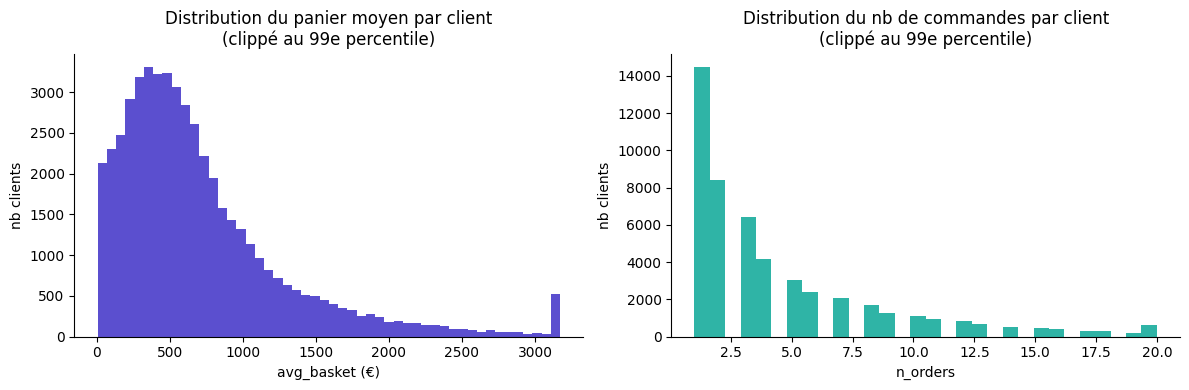

Panier moyen médian : 561€ | moyen : 724€
-> la moyenne est tirée vers le haut par une minorité de très gros paniers : cohérent avec les outliers/comptes B2B identifiés plus haut.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(customers_clean["avg_basket"].clip(upper=customers_clean["avg_basket"].quantile(0.99)),
             bins=50, color=PALETTE["primary"])
axes[0].set_title("Distribution du panier moyen par client\n(clippé au 99e percentile)")
axes[0].set_xlabel("avg_basket (€)")
axes[0].set_ylabel("nb clients")

axes[1].hist(customers_clean["n_orders"].clip(upper=customers_clean["n_orders"].quantile(0.99)),
             bins=30, color=PALETTE["secondary"])
axes[1].set_title("Distribution du nb de commandes par client\n(clippé au 99e percentile)")
axes[1].set_xlabel("n_orders")
axes[1].set_ylabel("nb clients")

plt.tight_layout()
plt.show()

print(f"Panier moyen médian : {customers_clean['avg_basket'].median():.0f}€ | moyen : {customers_clean['avg_basket'].mean():.0f}€")
print("-> la moyenne est tirée vers le haut par une minorité de très gros paniers : cohérent avec les outliers/comptes B2B identifiés plus haut.")

**Attention aux outliers B2B :** comme identifié en étape 2, une poignée de clients au panier moyen extrême (jusqu'à
~12 000€) tire fortement la moyenne vers le haut — la **médiane** (561€) est une mesure bien plus représentative du
client DTC typique que la moyenne (724€).

34.3 % des clients génèrent 80 % du chiffre d'affaires cumulé (total_spent).


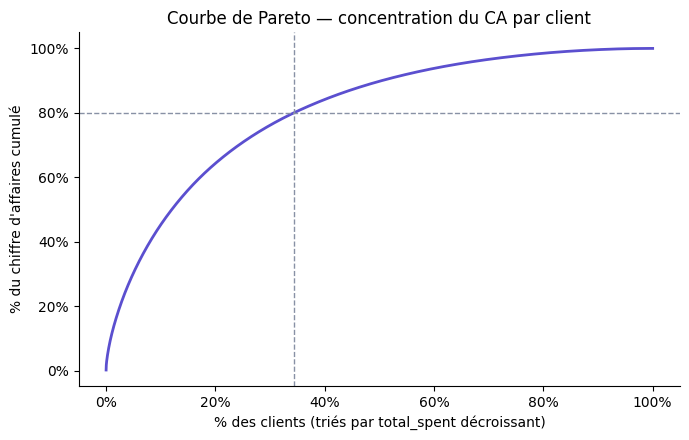

In [21]:
customers_sorted = customers_clean.sort_values("total_spent", ascending=False).reset_index(drop=True)
customers_sorted["cum_pct_revenue"] = customers_sorted["total_spent"].cumsum() / customers_sorted["total_spent"].sum() * 100
customers_sorted["cum_pct_clients"] = (customers_sorted.index + 1) / len(customers_sorted) * 100

pct_clients_for_80pct_rev = customers_sorted[customers_sorted["cum_pct_revenue"] >= 80]["cum_pct_clients"].iloc[0]
print(f"{pct_clients_for_80pct_rev:.1f} % des clients génèrent 80 % du chiffre d'affaires cumulé (total_spent).")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(customers_sorted["cum_pct_clients"], customers_sorted["cum_pct_revenue"], color=PALETTE["primary"], lw=2)
ax.axhline(80, color=PALETTE["neutral"], ls="--", lw=1)
ax.axvline(pct_clients_for_80pct_rev, color=PALETTE["neutral"], ls="--", lw=1)
ax.set_xlabel("% des clients (triés par total_spent décroissant)")
ax.set_ylabel("% du chiffre d'affaires cumulé")
ax.set_title("Courbe de Pareto — concentration du CA par client")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

**Loi de Pareto confirmée, mais moins extrême que le 80/20 classique** : il faut regarder le pourcentage affiché
ci-dessus (calculé sur les données réelles) plutôt que de présumer un 20 % — c'est une nuance à donner au CMO plutôt
qu'un chiffre tout fait.

### Saisonnalité

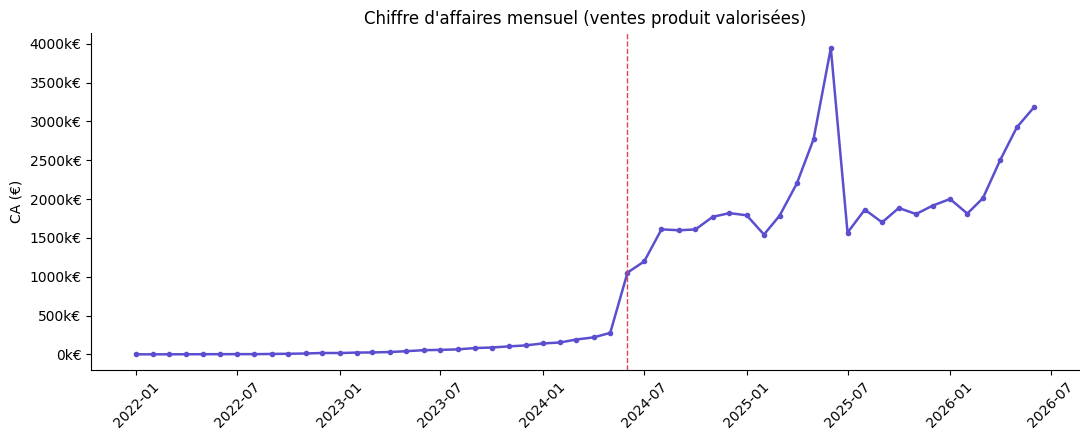

CA mai 2024 : 276 225€  ->  CA juin 2024 : 1 052 452€  (x3.8)

CA du mois de juin, chaque année (repère saisonnier) :
invoice_date
2022-06-01       1969.0
2023-06-01      53136.0
2024-06-01    1052452.0
2025-06-01    3943441.0
2026-06-01    3184095.0
Name: line_total, dtype: float64


In [22]:
monthly_rev = product_sales.set_index("invoice_date").resample("MS")["line_total"].sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_rev.index, monthly_rev.values, color=PALETTE["primary"], lw=1.8, marker="o", ms=3)
ax.axvline(pd.Timestamp("2024-06-01"), color=PALETTE["bad"], ls="--", lw=1)
ax.set_title("Chiffre d'affaires mensuel (ventes produit valorisées)")
ax.set_ylabel("CA (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k€"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

before = monthly_rev.loc["2024-05-01"]
after = monthly_rev.loc["2024-06-01"]
print(f"CA mai 2024 : {before:,.0f}€  ->  CA juin 2024 : {after:,.0f}€  (x{after/before:.1f})".replace(",", " "))

june_rev = monthly_rev[monthly_rev.index.month == 6]
print("\nCA du mois de juin, chaque année (repère saisonnier) :")
print(june_rev.round(0))

**Deux phénomènes bien différents se superposent ici, à ne pas confondre :**

1. **Une rupture de niveau nette entre mai et juin 2024** : le CA mensuel est multiplié par plus de 3,5 en un seul
   mois (ligne rouge sur le graphique), après une croissance progressive de 2022 à mi-2024. Une hausse aussi brutale
   et durable (le nouveau palier se maintient ensuite) ressemble davantage à un **changement de périmètre** —
   nouveau canal de vente, nouvel entrepôt/marché intégré à l'export, changement dans la façon dont les données sont
   collectées — qu'à une croissance organique classique. **Point de vigilance à documenter** plutôt qu'un fait acquis :
   comparer des CA avant/après juin 2024 sans le savoir fausserait n'importe quelle analyse de performance.
2. **Un pic récurrent chaque mois de juin**, une fois ce nouveau palier atteint (2025 et 2026) : le CA de juin
   dépasse nettement celui des mois voisins, ce qui correspond à un vrai pic saisonnier — cohérent avec la campagne
   `Summer_Sale` qu'on retrouve dans `campaigns.csv` (mi-juin à fin août).

**Implication marketing directe pour le Jour 3** : les campagnes devront être benchmarkées par rapport à cette double
base (rupture de niveau + saisonnalité de juin), pas par rapport à une moyenne annuelle plate — sinon on risque
d'attribuer à une campagne une hausse de CA qui vient en réalité de la saisonnalité ou du changement de périmètre.

### Géographie

In [23]:
country_stats = product_sales.groupby("country").agg(
    n_transactions=("invoice_id", "nunique"),
    revenue=("line_total", "sum"),
).sort_values("revenue", ascending=False)
country_stats["%_revenue"] = (country_stats["revenue"] / country_stats["revenue"].sum() * 100).round(1)
display(country_stats.head(10))

fr_share = country_stats.loc["France", "%_revenue"]
print(f"\nLa France représente {fr_share:.1f}% du CA (et {country_stats.loc['France','n_transactions']/country_stats['n_transactions'].sum()*100:.1f}% des factures).")

,n_transactions,revenue,%_revenue
country,,,
France,213145,47506025.08,92.1
Germany,4590,871084.94,1.7
United Kingdom,3656,719204.16,1.4
EIRE,706,560665.13,1.1
Netherlands,665,200689.93,0.4
Spain,984,197572.13,0.4
Belgium,1131,181449.32,0.4
Switzerland,729,162694.67,0.3
Portugal,755,146850.10,0.3



La France représente 92.1% du CA (et 91.8% des factures).


In [24]:
basket_by_country = product_sales.groupby("country").apply(
    lambda g: g.groupby("invoice_id")["line_total"].sum().mean(), include_groups=False
).sort_values(ascending=False)
top_countries = country_stats.head(8).index
print("Panier moyen par facture, pour les 8 principaux pays (par CA) :")
display(basket_by_country.loc[top_countries].round(1).rename("panier moyen (€)"))

Panier moyen par facture, pour les 8 principaux pays (par CA) :


country
France            222.9
Germany           189.8
United Kingdom    196.7
EIRE              794.1
Netherlands       301.8
Spain             200.8
Belgium           160.4
Switzerland       223.2
Name: panier moyen (€), dtype: float64

**Biais géographique clair et à documenter :** la base est **très largement dominée par la France** (>90 % du CA).
C'est cohérent pour une marque française mais ça veut dire que toute segmentation ou tout test A/B (Jour 4) mené sur
l'ensemble de la base sera en réalité un test *quasi exclusivement France* — une conclusion "ça marche" ne se
généralise pas forcément aux autres pays, à mentionner comme limite dans la présentation finale. Le panier moyen
varie par ailleurs sensiblement d'un pays à l'autre, ce qui suggère des comportements d'achat différents (paniers
plus gros sur certains marchés d'export, cohérent avec des achats moins fréquents mais plus groupés).

### Relations entre variables

Corrélation récence <-> montant dépensé (monetary) : -0.12
Corrélation fréquence <-> panier moyen              : 0.01


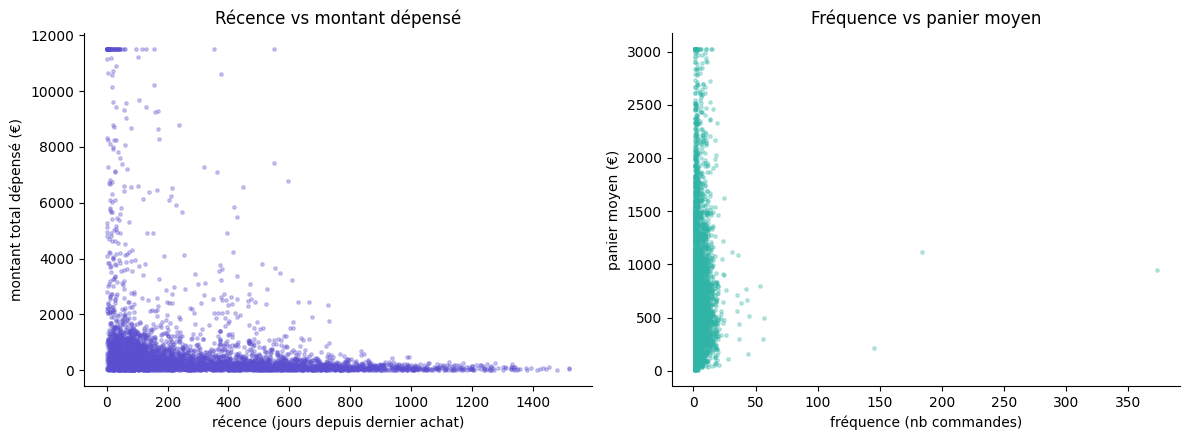

In [25]:
sample = customers_clean.dropna(subset=["recency_days_recalc", "monetary", "frequency", "avg_basket"])
corr_recency_monetary = sample["recency_days_recalc"].corr(sample["monetary"])
corr_freq_basket = sample["frequency"].corr(sample["avg_basket"])

print(f"Corrélation récence <-> montant dépensé (monetary) : {corr_recency_monetary:.2f}")
print(f"Corrélation fréquence <-> panier moyen              : {corr_freq_basket:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sub = sample.sample(min(5000, len(sample)), random_state=42)

axes[0].scatter(sub["recency_days_recalc"], sub["monetary"].clip(upper=sub["monetary"].quantile(0.99)),
                s=6, alpha=0.3, color=PALETTE["primary"])
axes[0].set_xlabel("récence (jours depuis dernier achat)")
axes[0].set_ylabel("montant total dépensé (€)")
axes[0].set_title("Récence vs montant dépensé")

axes[1].scatter(sub["frequency"], sub["avg_basket"].clip(upper=sub["avg_basket"].quantile(0.99)),
                s=6, alpha=0.3, color=PALETTE["secondary"])
axes[1].set_xlabel("fréquence (nb commandes)")
axes[1].set_ylabel("panier moyen (€)")
axes[1].set_title("Fréquence vs panier moyen")

plt.tight_layout()
plt.show()

**Récence vs montant dépensé :** la relation n'est pas franchement linéaire (coefficient de corrélation modéré) —
elle ressemble plus à un nuage en "L" : beaucoup de clients récents avec des montants variés, et les gros montants
totaux concentrés chez des clients à la fois récents et actifs. C'est un signal encourageant pour une segmentation
RFM (Jour 2), où récence et montant apportent chacun une information distincte plutôt que redondante.

**Fréquence vs panier moyen :** corrélation faible — les clients qui achètent souvent n'ont pas nécessairement un
panier plus gros à chaque commande. Ça suggère que "fréquence" et "panier moyen" sont deux leviers marketing
différents (fidélisation vs montée en gamme / cross-sell), pas un seul et même comportement.

On voit déjà, à l'œil, des zones plus denses dans les nuages de points ci-dessus — des **segments "naturellement
visibles"** avant toute modélisation, ce qui sera formalisé avec le RFM/clustering du Jour 2.

### Catégories de produits

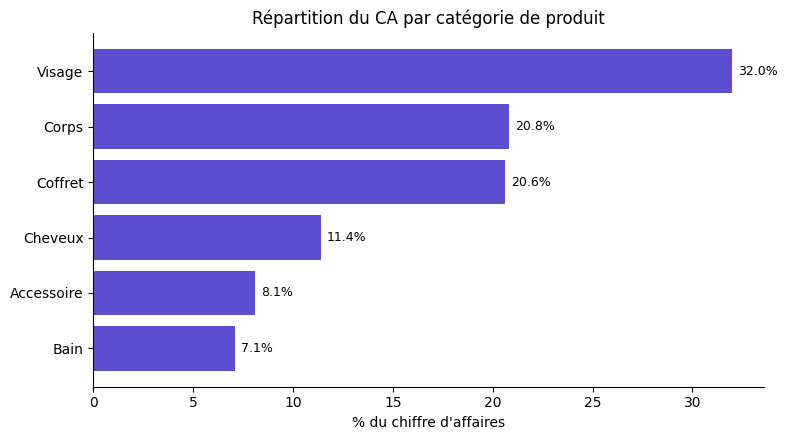

In [26]:
cat_revenue = product_sales.groupby("category")["line_total"].sum().sort_values(ascending=False)
cat_share = (cat_revenue / cat_revenue.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(cat_share.index[::-1], cat_share.values[::-1], color=PALETTE["primary"])
ax.set_xlabel("% du chiffre d'affaires")
ax.set_title("Répartition du CA par catégorie de produit")
for i, v in enumerate(cat_share.values[::-1]):
    ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Répartition plutôt équilibrée**, sans catégorie totalement dominante — Visage et Corps sont en tête (cohérent avec
le cœur de gamme d'une marque cosmétique DTC), suivis de Cheveux, Accessoire, Bain et Coffret. Ce sera le point de
comparaison du Jour 2 pour voir si certains segments RFM ont une affinité produit particulière.

### Données zero-party

In [27]:
zp_cols = ["declared_preference", "age_bracket", "life_stage", "urban_density"]
fill_rate = (customers[zp_cols].notna().mean() * 100).round(1)
display(fill_rate.rename("% de clients renseignés"))

declared_preference    38.1
age_bracket            42.7
life_stage             22.5
urban_density          19.8
Name: % de clients renseignés, dtype: float64

**Cohérence attendue :** des taux de remplissage entre 18 % et 42 % sont dans la norme pour de la donnée
**zero-party** (déclarée volontairement par le client, donc jamais exhaustive) — ce n'est pas un défaut du pipeline
de données, mais une limite structurelle à documenter : toute segmentation basée sur ces colonnes ne pourra couvrir
qu'une minorité de la base, et il faut vérifier qu'elle n'est pas biaisée (les clients qui répondent aux enquêtes
sont-ils représentatifs du reste ?).

## Étape 4 — Hypothèses marketing

Sur la base de l'EDA ci-dessus, voici 5 hypothèses à valider ou invalider avec la segmentation RFM du Jour 2 :

1. *Je suppose que* **28,8 % des clients n'ont acheté qu'une seule fois** *implique* qu'une partie significative de la
   base CRM est composée d'acheteurs opportunistes plutôt que de clients fidèles, *ce qui suggère* de sortir ces
   clients "one-shot" du programme d'emailing générique et de leur appliquer un scénario de réactivation dédié plutôt
   que le même contenu qu'aux clients récurrents.

2. *Je suppose que* **la corrélation faible entre fréquence et panier moyen** *implique* qu'il existe au moins deux
   leviers marketing distincts (faire acheter plus souvent vs faire dépenser plus par commande), *ce qui suggère* de
   construire deux types de campagnes différenciées — l'une orientée fréquence/fidélité, l'autre orientée montée en
   gamme/cross-sell — plutôt qu'une seule campagne générique.

3. *Je suppose que* **la forte concentration du CA sur une minorité de clients** (Pareto) *implique* qu'un petit
   groupe de "meilleurs clients" pèse disproportionnellement dans le chiffre d'affaires, *ce qui suggère* de créer un
   segment VIP dédié avec une communication et des offres différenciées, en excluant les comptes suspectés B2B
   identifiés en étape 2 pour ne pas fausser ce segment avec des consommateurs particuliers.

4. *Je suppose que* **la sur-représentation de la France (>90 % du CA)** *implique* que les enseignements tirés de la
   base actuelle sont surtout valables sur le marché français, *ce qui suggère* de ne pas généraliser directement les
   futurs tests A/B (Jour 4) aux marchés d'export sans validation spécifique, et d'envisager un test dédié si Lumina &
   Co veut investir sur l'international.

5. *Je suppose que* **le pic de CA récurrent chaque mois de juin, superposé à la rupture de niveau de mi-2024**
   *implique* qu'une partie de la performance des campagnes mesurée en Jour 3 est en réalité portée par la
   saisonnalité naturelle et par ce changement de périmètre plutôt que par les campagnes elles-mêmes, *ce qui suggère*
   de comparer chaque campagne à sa période équivalente de l'année précédente (ou à un groupe témoin), et de vérifier
   d'abord ce qui explique la rupture de mi-2024 avant d'en tirer des conclusions de croissance.

## Conclusion et transition vers le Jour 2

**Réponse à la première question du CMO** — *"On envoie les mêmes emails à tout le monde, c'est un problème ?"* :
oui, clairement. 28,8 % des clients sont des acheteurs uniques, le CA est concentré sur une minorité de clients, et
fréquence / panier moyen ne racontent pas la même histoire selon les clients. Traiter tout le monde pareil revient à
ignorer des différences de comportement déjà visibles avant toute modélisation.

**Ce qu'on emporte pour le Jour 2 (segmentation RFM)** :
- Recalculer récence / fréquence / montant depuis `transactions.csv` plutôt que d'utiliser les agrégats de
  `customers.csv` (non fiables, cf. étape 2).
- Restreindre l'univers RFM aux lignes `product_sales` (hors frais, hors retours, hors lignes sans `customer_id`).
- Isoler ou traiter à part les comptes suspectés B2B (`is_high_value_outlier`) et le bloc `customer_id >= 62600`
  (`is_manual_list_block`) pour ne pas fausser les clusters.
- Garder en tête le biais géographique France, la rupture de niveau de CA à mi-2024 et la faible couverture des
  données zero-party comme limites à mentionner dans la présentation finale.